# KDD sobre dataset de viviendas

In [743]:
#Imports

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Análisis exploratorio de los datos (EDA)

## Análisis general

In [ ]:
# Carga del dataset inicial
ruta_ventas = "Datos/ventas.csv" 

df = pd.read_csv(ruta_ventas)

print("Número de observaciones:", df.shape[0])
print("Número de variables:", df.shape[1])

display(df.head())

Número de observaciones: 11826
Número de variables: 9


,zona,titulo,precio,metros,habitaciones,ascensor,localizacion,planta,baños
0,ciudad-lineal,"Piso en calle de San Marcelo, 22, Ventas, Madrid",355000,69,"2,00",S,EXTERIOR,5ª,1
1,carabanchel,"Piso en calle Cabo Nicolás Mur, San Isidro, Ma...",149000,91,"3,00",N,EXTERIOR,1ª,1
2,centro,"Piso en calle de Rodas, Lavapiés-Embajadores, ...",195000,36,"1,00",S,NaN,2ª,1
3,usera,"Piso en calle de Ferroviarios, Almendrales, Ma...",195000,58,"1,00",S,INTERIOR,BAJO,1
4,tetuan,"Dúplex en Bellas Vistas, Madrid",715000,140,"3,00",S,EXTERIOR,2ª,1


In [745]:
# Información general de columnas

tabla_info = pd.DataFrame({
    "Variable": df.columns,
    "Tipo de dato": df.dtypes.astype(str).values,
    "Valores no nulos": df.notna().sum().values,
    "Valores nulos": df.isna().sum().values,
    "% nulos": (df.isna().mean().values * 100).round(2),
    "Valores únicos": df.nunique().values
})

tabla_info

,Variable,Tipo de dato,Valores no nulos,Valores nulos,% nulos,Valores únicos
0,zona,str,11826,0,"0,00",21
1,titulo,str,11826,0,"0,00",5499
2,precio,int64,11826,0,"0,00",1880
3,metros,int64,11826,0,"0,00",615
4,habitaciones,float64,11460,366,"3,09",17
5,ascensor,str,11033,793,"6,71",2
6,localizacion,str,10730,1096,"9,27",2
7,planta,str,10601,1225,"10,36",27
8,baños,int64,11826,0,"0,00",7


Análisis de la variable objetivo

In [746]:
variable_objetivo = "precio" 
resumen = df[[variable_objetivo]].describe()

(resumen.style
 .format("{:,.0f}", subset=(['count'], resumen.columns))
 .format("{:,.0f} €", subset=(resumen.index.drop('count'), resumen.columns))
)

,precio
count,"11,826"
mean,"1,030,501 €"
std,"1,237,718 €"
min,"12,000 €"
25%,"289,000 €"
50%,"620,000 €"
75%,"1,329,000 €"
max,"23,000,000 €"


N° de registros duplicados

In [747]:
duplicados = df.duplicated().sum()

print("Número de registros duplicados:", duplicados)

Número de registros duplicados: 688


## Análisis univariante

In [748]:
#Definición de los tipos de variables
variables_numericas = ["precio", "metros", "habitaciones", "baños"]

variables_categoricas = [
    "zona",
    "ascensor",
    "localizacion",
    "planta"
]

variables_textuales = [
    "titulo"
]

### Distribución de las variables numéricas

In [749]:
pd.set_option(
    "display.float_format",
    lambda x: f"{x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
)

df.describe()

,precio,metros,habitaciones,baños
count,"11.826,00","11.826,00","11.460,00","11.826,00"
mean,"1.030.501,46","153,79","2,85","1,18"
std,"1.237.717,63","766,22","1,43","0,57"
min,"12.000,00","11,00","1,00","1,00"
25%,"289.000,00","68,00","2,00","1,00"
50%,"620.000,00","103,00","3,00","1,00"
75%,"1.329.000,00","160,00","3,00","1,00"
max,"23.000.000,00","75.000,00","20,00","7,00"


### Histogramas

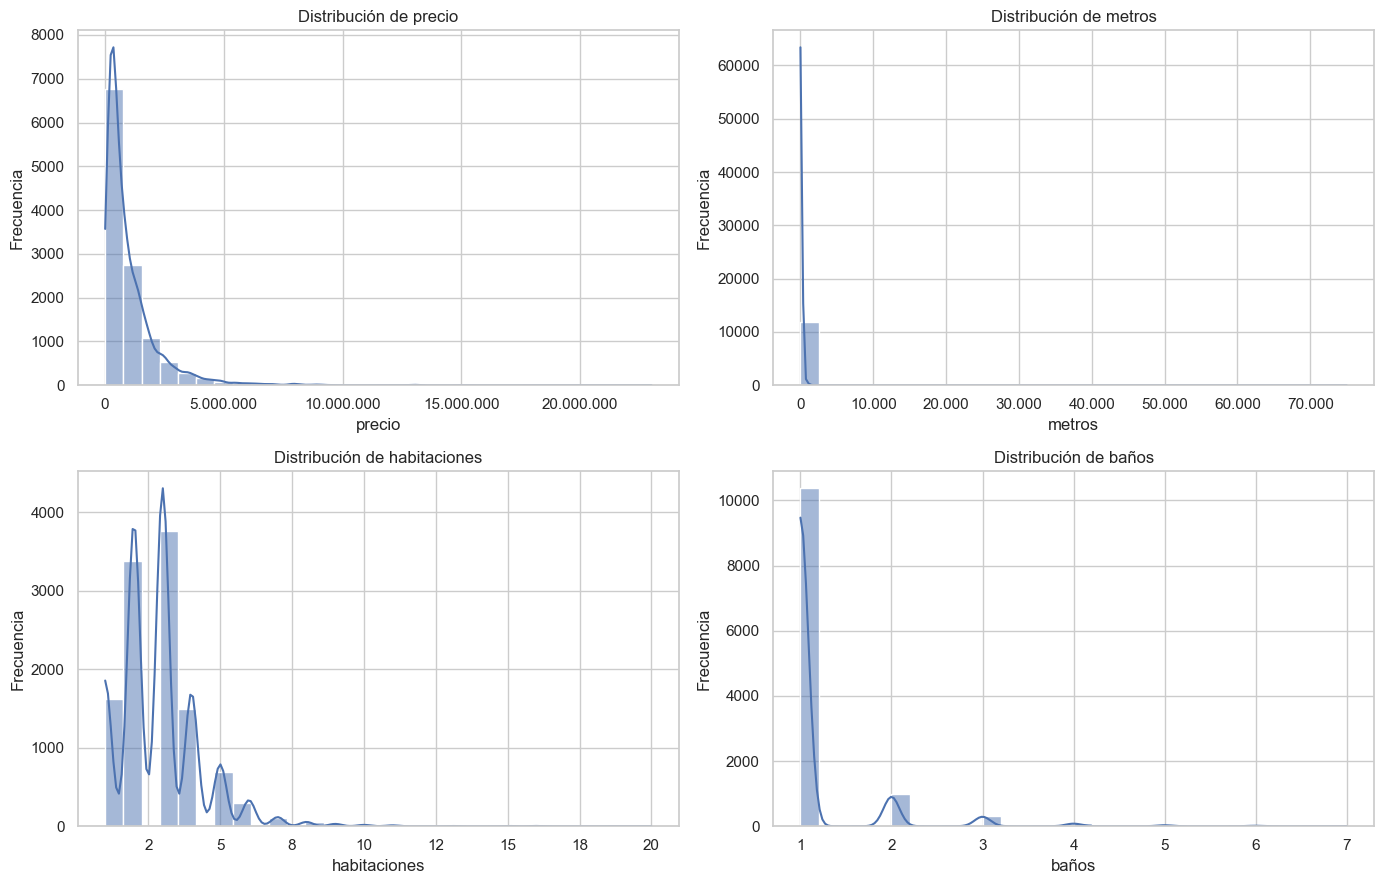

In [750]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

def formato_miles(x, pos):
    return f"{x:,.0f}".replace(",", ".")

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, col in enumerate(variables_numericas):
    sns.histplot(
        data=df,
        x=col,
        bins=30,
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(f"Distribución de {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frecuencia")

    axes[i].xaxis.set_major_formatter(FuncFormatter(formato_miles))

plt.tight_layout()
plt.show()

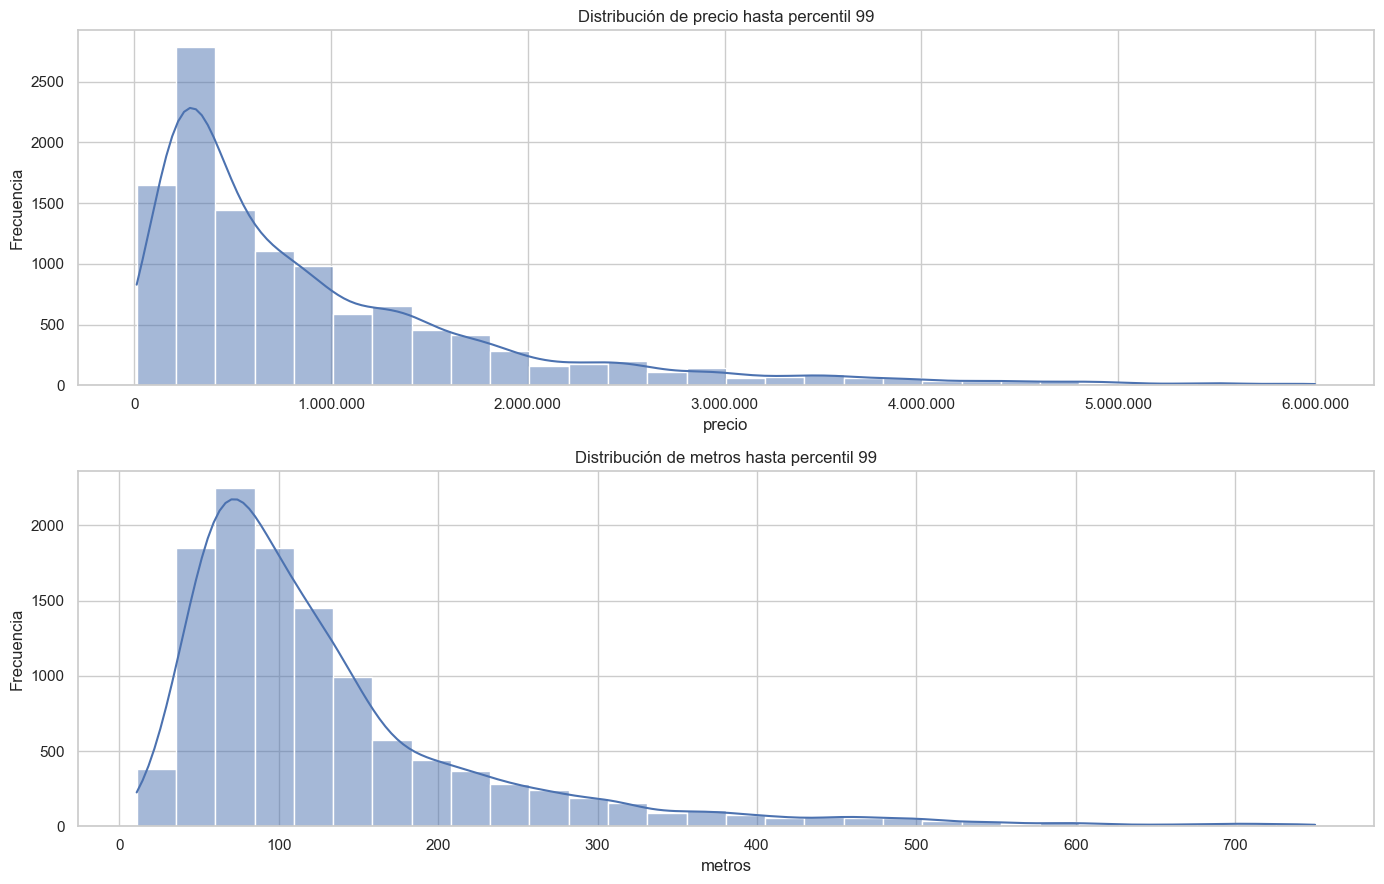

In [751]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

def formato_miles(x, pos):
    return f"{x:,.0f}".replace(",", ".")

fig, axes = plt.subplots(2, figsize=(14, 9))
axes = axes.flatten()

variables = ["precio","metros"]

for i, col in enumerate(variables):
    
    if col in ["precio", "metros"]:
        limite = df[col].quantile(0.99)
        datos_plot = df[df[col] <= limite]
        titulo = f"Distribución de {col} hasta percentil 99"
    else:
        datos_plot = df
        titulo = f"Distribución de {col}"
    
    sns.histplot(
        data=datos_plot,
        x=col,
        bins=30,
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(titulo)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frecuencia")

    axes[i].xaxis.set_major_formatter(FuncFormatter(formato_miles))

plt.tight_layout()
plt.show()

### Diagramas de caja

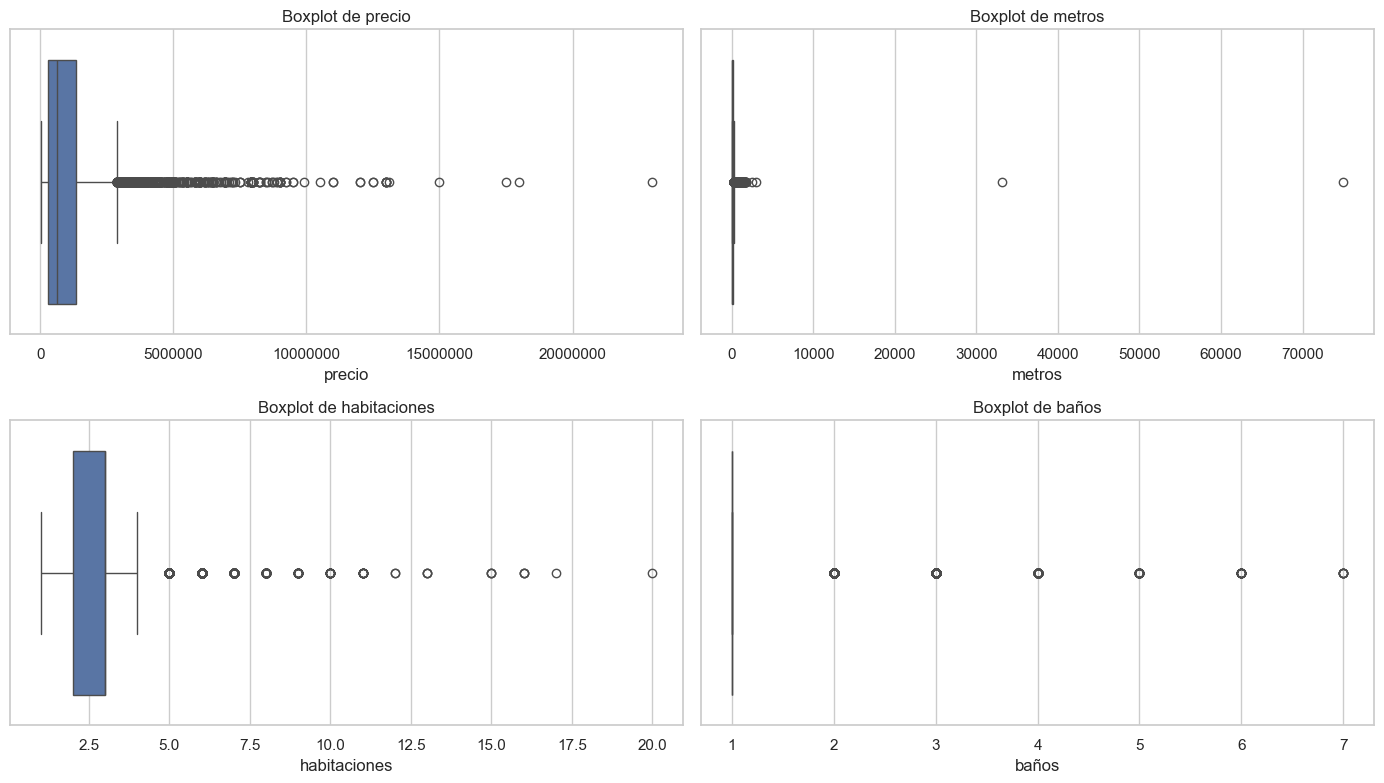

In [752]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(variables_numericas):
    sns.boxplot(
        data=df,
        x=col,
        ax=axes[i]
    )
    
    axes[i].set_title(f"Boxplot de {col}")
    axes[i].set_xlabel(col)
    
    axes[i].ticklabel_format(style='plain', axis='x')

plt.tight_layout()
plt.show()

### Diagramas de barras de variables categóricas

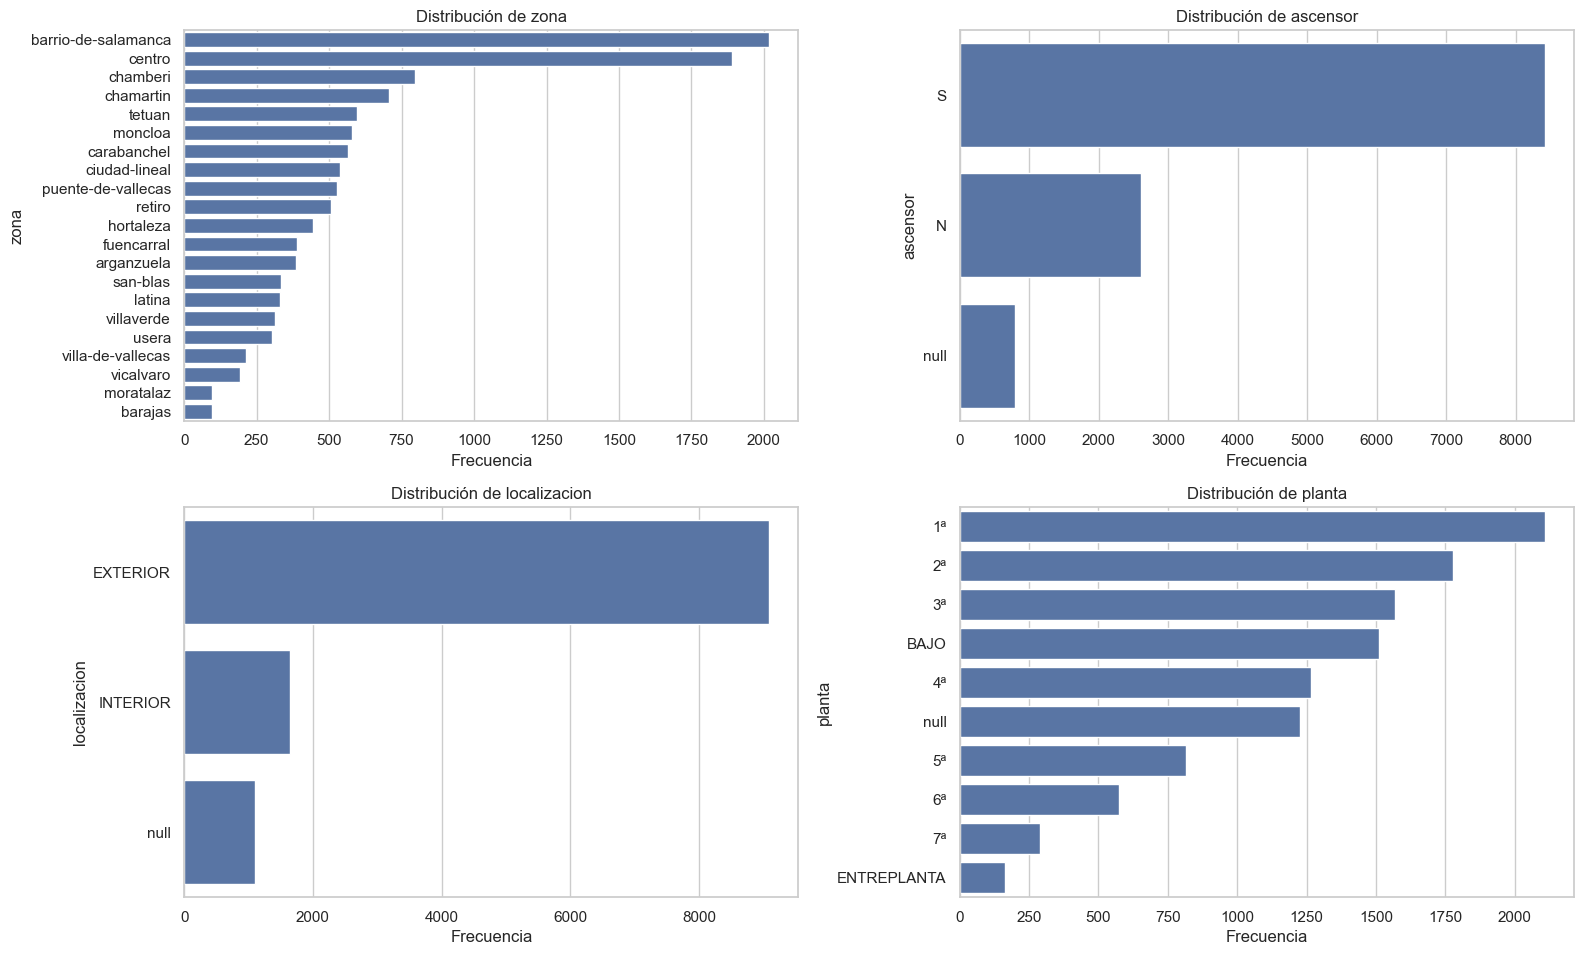

In [753]:
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(variables_categoricas):

    datos_plot = df.copy()
    datos_plot[col] = datos_plot[col].fillna("null").astype(str)

    if col == "zona":
        orden = datos_plot[col].value_counts().index
    else:
        orden = datos_plot[col].value_counts().head(10).index

    sns.countplot(
        data=datos_plot[datos_plot[col].isin(orden)],
        y=col,
        order=orden,
        ax=axes[i]
    )

    axes[i].set_title(f"Distribución de {col}")
    axes[i].set_xlabel("Frecuencia")
    axes[i].set_ylabel(col)

for j in range(len(variables_categoricas), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [754]:
tabla_planta = (
    df["planta"]
    .value_counts(dropna=False)
    .reset_index()
)

tabla_planta.columns = ["Planta", "Frecuencia"]

tabla_planta["Porcentaje"] = (
    tabla_planta["Frecuencia"] / len(df) * 100
).round(2)

tabla_planta

,Planta,Frecuencia,Porcentaje
0,1ª,2108,"17,83"
1,2ª,1779,"15,04"
2,3ª,1570,"13,28"
3,BAJO,1509,"12,76"
4,4ª,1266,"10,71"
5,NaN,1225,"10,36"
6,5ª,816,"6,90"
7,6ª,574,"4,85"
8,7ª,289,"2,44"
9,ENTREPLANTA,163,"1,38"


## Análisis bivariante

### Variables numéricas frente a variable objetivo (precio)

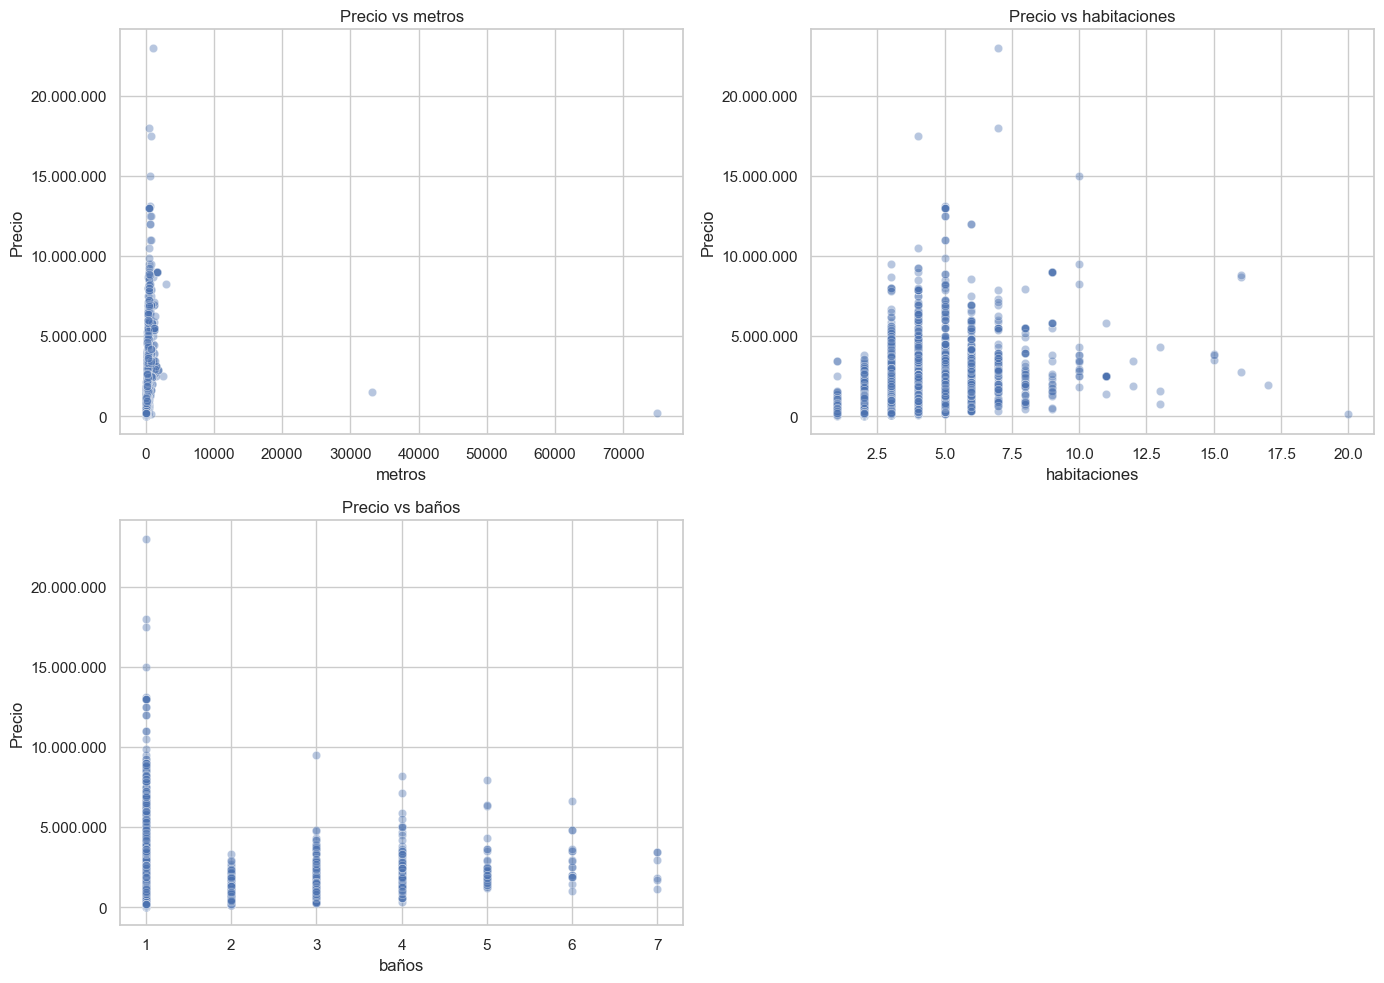

In [755]:
import matplotlib.ticker as mticker

variables_explicativas_numericas = [
    col for col in variables_numericas if col != "precio"
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(variables_explicativas_numericas):
    
    sns.scatterplot(
        data=df,
        x=col,
        y="precio",
        alpha=0.4,
        ax=axes[i]
    )
    
    axes[i].set_title(f"Precio vs {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Precio")

    # Evitar notación científica en el eje del precio
    axes[i].yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", "."))
    )

for j in range(len(variables_explicativas_numericas), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

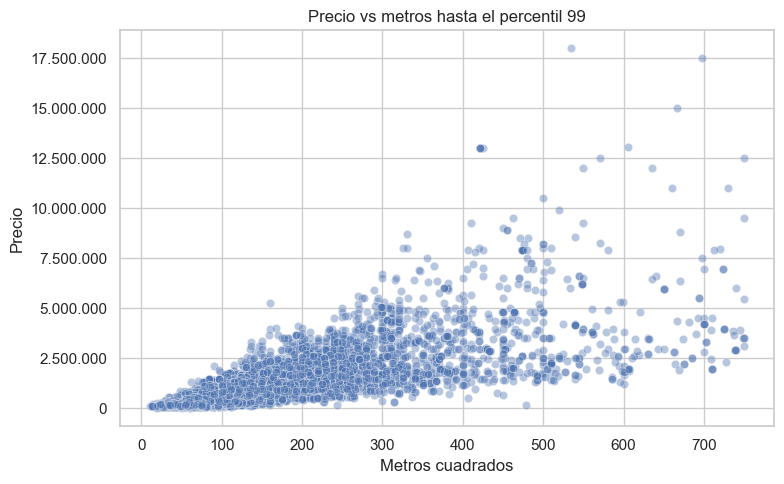

In [756]:
import matplotlib.ticker as mticker

limite_metros = df["metros"].quantile(0.99)

df_plot = df[df["metros"] <= limite_metros]

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_plot,
    x="metros",
    y="precio",
    alpha=0.4
)

plt.title("Precio vs metros hasta el percentil 99")
plt.xlabel("Metros cuadrados")
plt.ylabel("Precio")

plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", "."))
)

plt.tight_layout()
plt.show()

### Análisis del n° de baños respecto al precio

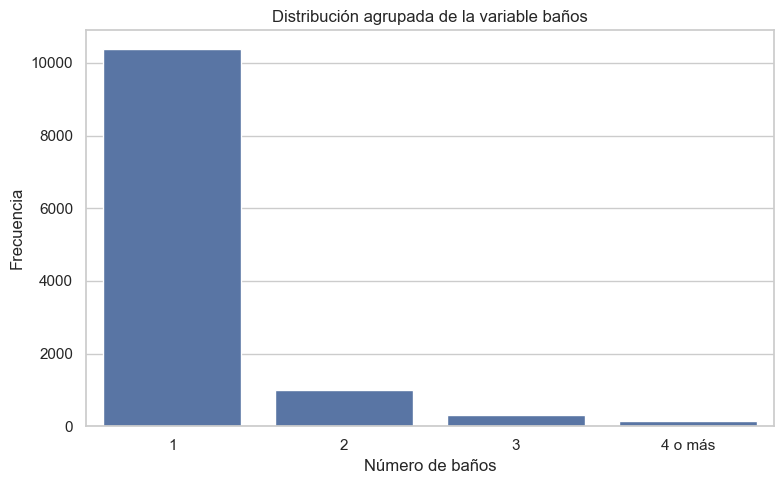

In [757]:
df_plot = df.copy()

df_plot["baños_agrupado"] = df_plot["baños"].apply(
    lambda x: "4 o más" if x >= 4 else str(int(x))
)

orden_baños = ["1", "2", "3", "4 o más"]

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_plot,
    x="baños_agrupado",
    order=orden_baños
)

plt.title("Distribución agrupada de la variable baños")
plt.xlabel("Número de baños")
plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

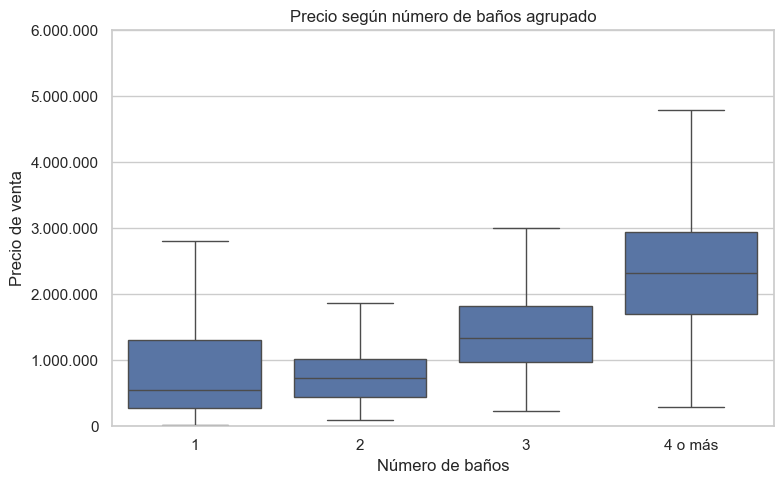

In [758]:
import matplotlib.ticker as mticker

limite_precio = df["precio"].quantile(0.99)

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_plot,
    x="baños_agrupado",
    y="precio",
    order=orden_baños,
    showfliers=False
)

plt.ylim(0, limite_precio)

plt.title("Precio según número de baños agrupado")
plt.xlabel("Número de baños")
plt.ylabel("Precio de venta")

plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", "."))
)

plt.tight_layout()
plt.show()

### Variables categóricas vs precio

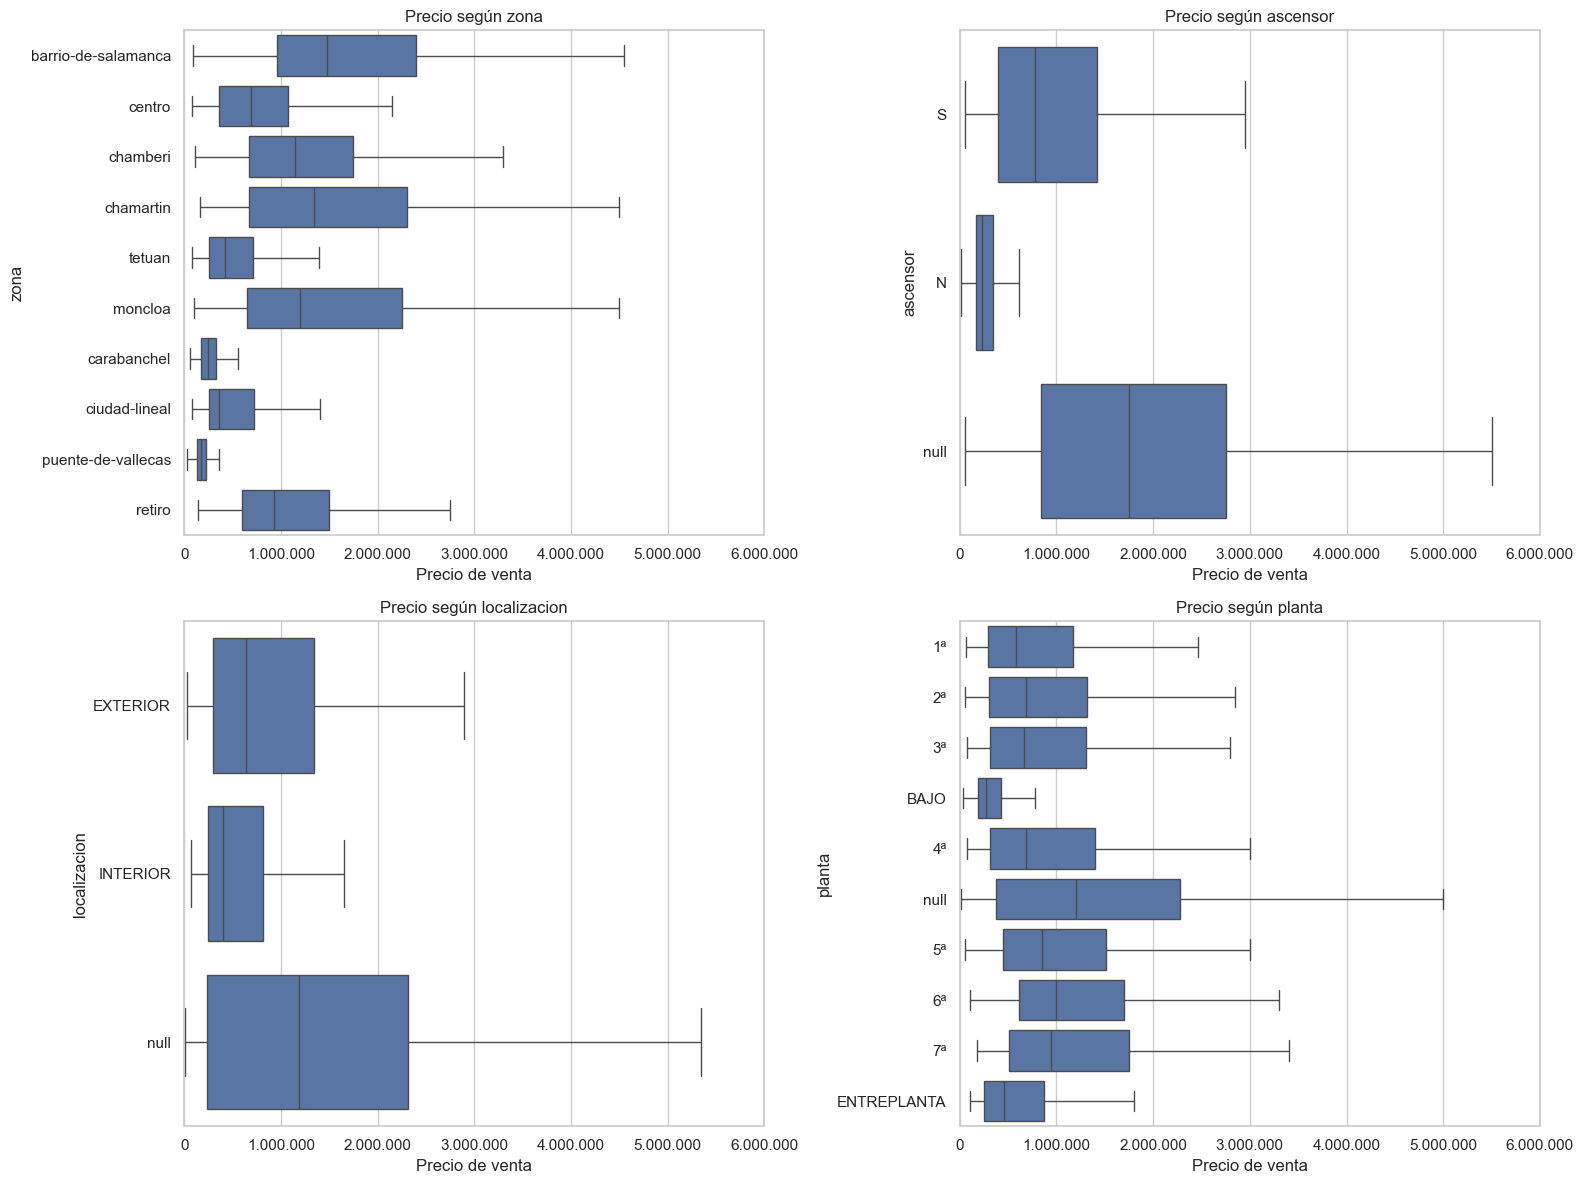

In [759]:
import matplotlib.ticker as mticker

df_plot = df.copy()

for col in variables_categoricas:
    df_plot[col] = df_plot[col].fillna("null").astype(str)

limite_precio = df_plot["precio"].quantile(0.99)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(variables_categoricas):
    
    categorias = df_plot[col].value_counts().head(10).index
    datos_col = df_plot[df_plot[col].isin(categorias)]
    
    sns.boxplot(
        data=datos_col,
        x="precio",
        y=col,
        order=categorias,
        ax=axes[i],
        showfliers=False
    )
    
    axes[i].set_title(f"Precio según {col}")
    axes[i].set_xlabel("Precio de venta")
    axes[i].set_ylabel(col)

    axes[i].set_xlim(0, limite_precio)

    axes[i].xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", "."))
    )

plt.tight_layout()
plt.show()

### Análisis del precio por distrito

In [760]:
precio_por_zona = (
    df.groupby("zona")["precio"]
    .agg(
        numero_viviendas="count",
        precio_medio="mean",
        precio_mediano="median"
    )
    .sort_values("precio_mediano", ascending=False)
)

display(precio_por_zona.head(20))

,numero_viviendas,precio_medio,precio_mediano
zona,,,
barrio-de-salamanca,2018,"1.966.802,05","1.479.000,00"
chamartin,706,"1.767.126,30","1.339.000,00"
moncloa,580,"1.620.871,17","1.200.000,00"
chamberi,796,"1.498.335,73","1.142.000,00"
retiro,508,"1.310.153,79","932.500,00"
hortaleza,444,"1.190.754,57","795.000,00"
fuencarral,391,"892.204,09","720.000,00"
centro,1890,"862.305,90","695.000,00"
barajas,97,"555.625,66","450.000,00"


### Matriz de correlación

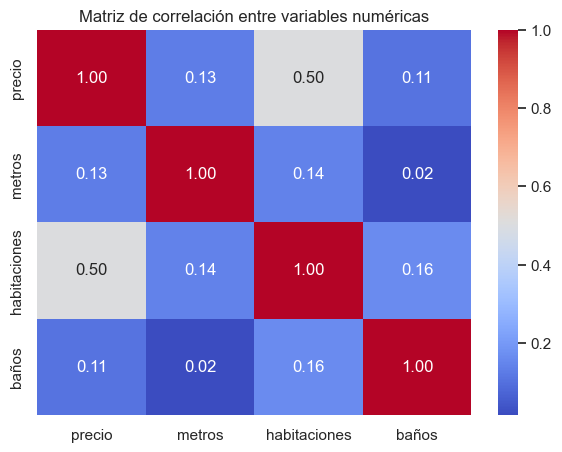

In [761]:
corr = df[variables_numericas].corr()

plt.figure(figsize=(7, 5))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de correlación entre variables numéricas")
plt.show()

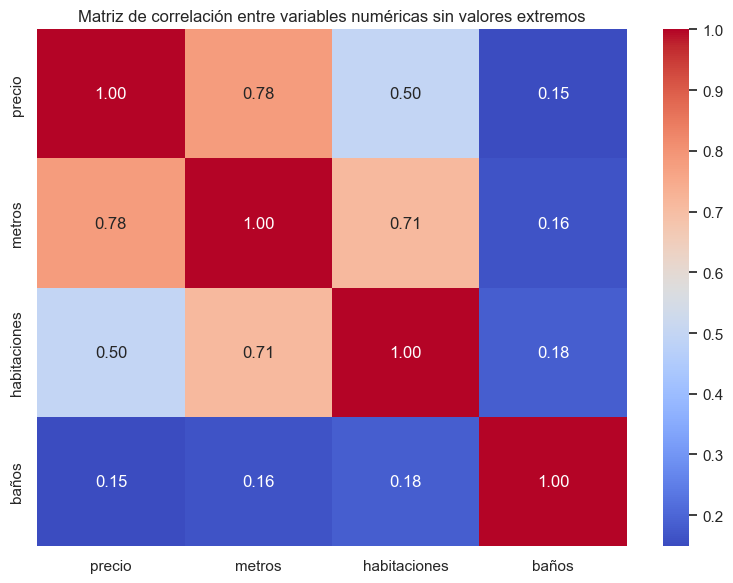

In [762]:
df_corr = df.copy()

limite_precio = df_corr["precio"].quantile(0.99)
limite_metros = df_corr["metros"].quantile(0.99)

df_corr_filtrado = df_corr[
    (df_corr["precio"] <= limite_precio) &
    (df_corr["metros"] <= limite_metros)
]

matriz_corr_filtrada = df_corr_filtrado[variables_numericas].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    matriz_corr_filtrada,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de correlación entre variables numéricas sin valores extremos")
plt.tight_layout()
plt.show()

### Análisis por m2

In [763]:
df["precio_m2"] = df["precio"] / df["metros"]
df["precio_m2"] = df["precio_m2"].replace([np.inf, -np.inf], np.nan)

df["precio_m2"].describe()

count   11.826,00
mean     6.654,73
std      3.581,97
min          2,56
25%      3.909,09
50%      6.000,00
75%      8.725,49
max     33.644,86
Name: precio_m2, dtype: float64

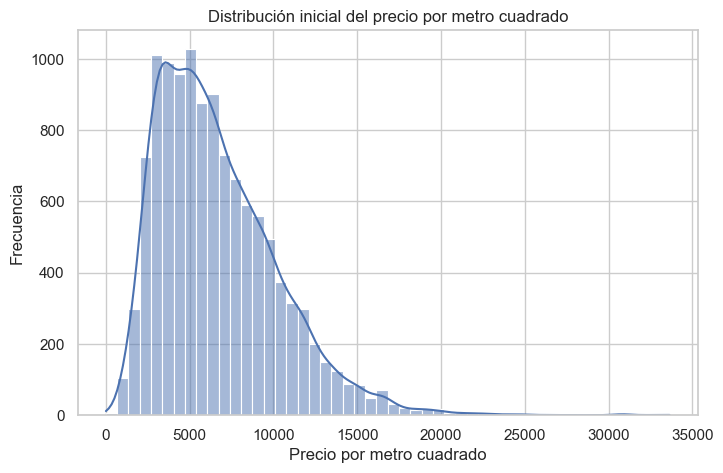

In [764]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="precio_m2",
    bins=50,
    kde=True
)

plt.title("Distribución inicial del precio por metro cuadrado")
plt.xlabel("Precio por metro cuadrado")
plt.ylabel("Frecuencia")
plt.show()

In [765]:
precio_m2_por_zona = (
    df.groupby("zona")["precio_m2"]
    .agg(
        numero_viviendas="count",
        precio_m2_medio="mean",
        precio_m2_mediano="median"
    )
    .sort_values("precio_m2_mediano", ascending=False)
)

display(precio_m2_por_zona.head(20))

,numero_viviendas,precio_m2_medio,precio_m2_mediano
zona,,,
barrio-de-salamanca,2018,"11.002,39","10.679,39"
chamberi,796,"8.844,52","8.517,58"
retiro,508,"8.645,24","8.273,29"
chamartin,706,"7.782,47","7.400,00"
centro,1890,"7.535,85","7.214,02"
moncloa,580,"5.662,92","5.457,89"
arganzuela,386,"5.716,32","5.447,66"
tetuan,596,"5.468,53","5.291,29"
hortaleza,444,"5.276,46","5.087,95"


# Preprocesamiento e ingeniería de características

In [766]:
df_pre = df.copy()

print("Dimensiones antes del preprocesamiento:", df_pre.shape)

Dimensiones antes del preprocesamiento: (11826, 10)


## Eliminación de duplicados

In [767]:
filas_antes = df_pre.shape[0]

df_pre = df_pre.drop_duplicates()

filas_despues = df_pre.shape[0]

print("Duplicados eliminados:", filas_antes - filas_despues)
print("Dimensiones:", df_pre.shape)

Duplicados eliminados: 688
Dimensiones: (11138, 10)


## Tratamiento de valores inválidos en la variable target

In [768]:
filas_antes = df_pre.shape[0]

df_pre = df_pre[df_pre["precio"].notna()]
df_pre = df_pre[df_pre["precio"] > 0]

filas_despues = df_pre.shape[0]

print("Registros eliminados por precio nulo o inválido:", filas_antes - filas_despues)
print("Dimensiones:", df_pre.shape)

Registros eliminados por precio nulo o inválido: 0
Dimensiones: (11138, 10)


## Tratamiento de nulos

In [769]:
nulos_antes = df_pre.isna().sum()

# Habitaciones: imputación por mediana de zona
df_pre["habitaciones"] = df_pre["habitaciones"].fillna(
    df_pre.groupby("zona")["habitaciones"].transform("median")
)

# Habitaciones: imputación de posibles nulos restantes con mediana global
df_pre["habitaciones"] = df_pre["habitaciones"].fillna(
    df_pre["habitaciones"].median()
)

# Variables categóricas: categoría explícita para valores desconocidos
df_pre["ascensor"] = df_pre["ascensor"].fillna("Desconocido")
df_pre["localizacion"] = df_pre["localizacion"].fillna("Desconocido")
df_pre["planta"] = df_pre["planta"].fillna("Desconocido")

nulos_despues = df_pre.isna().sum()

resumen_nulos = pd.DataFrame({
    "Nulos antes": nulos_antes,
    "Nulos después": nulos_despues,
    "Nulos tratados": nulos_antes - nulos_despues
})

resumen_nulos["% nulos después"] = (
    resumen_nulos["Nulos después"] / len(df_pre) * 100
).round(2)



resumen_nulos

,Nulos antes,Nulos después,Nulos tratados,% nulos después
zona,0,0,0,"0,00"
titulo,0,0,0,"0,00"
precio,0,0,0,"0,00"
metros,0,0,0,"0,00"
habitaciones,358,0,358,"0,00"
ascensor,751,0,751,"0,00"
localizacion,1033,0,1033,"0,00"
planta,1166,0,1166,"0,00"
baños,0,0,0,"0,00"
precio_m2,0,0,0,"0,00"


## Transformación y creación de nuevas variables

### Transformación de la variable planta a numérica

In [770]:
def transformar_planta(valor):
    if pd.isna(valor):
        return np.nan
    
    valor = str(valor).strip().upper()
    
    if valor == "DESCONOCIDO":
        return np.nan
    
    if valor == "BAJO":
        return 0
    
    if valor == "ENTREPLANTA":
        return 0.5
    
    if valor in ["SÓTANO", "SOTANO"]:
        return -1
    
    valor = valor.replace("ª", "")
    
    try:
        return float(valor)
    except:
        return np.nan 
    
df_pre["planta_num"] = df_pre["planta"].apply(transformar_planta)

### Creación de la variable distancia al metro (distance_to_metro)

#### Geochaching

In [ ]:
import pandas as pd
import re

from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter


def limpiar_titulo(titulo):

    if pd.isna(titulo):
        return None
    
    titulo = str(titulo).strip()
    
    patrones = [
        r"^Piso en\s+",
        r"^Dúplex en\s+",
        r"^Ático en\s+",
        r"^Chalet en\s+",
        r"^Casa en\s+",
        r"^Estudio en\s+",
        r"^Loft en\s+",
        r"^Apartamento en\s+",
        r"^Finca rústica en\s+",
        r"^Terreno en\s+",
        r"^Local en\s+",
    ]
    
    for patron in patrones:
        titulo = re.sub(patron, "", titulo, flags=re.IGNORECASE)
    
    return titulo.strip()


def contiene_numero(texto):
    """
    Comprueba si un texto contiene algún número.
    """
    if pd.isna(texto):
        return False
    
    return bool(re.search(r"\b\d+\b", str(texto)))


def quitar_numero(texto):
    """
    Elimina números de una cadena de texto.
    """
    if pd.isna(texto):
        return None
    
    texto = str(texto)
    texto = re.sub(r",?\s*\b\d+\b", "", texto)
    texto = re.sub(r"\s+", " ", texto)
    
    return texto.strip(" ,")


def generar_direcciones_candidatas(titulo, zona=None):
    """
    Genera varias direcciones posibles para geolocalizar una vivienda.
    Las direcciones se prueban de más específica a más general.
    """
    titulo_limpio = limpiar_titulo(titulo)
    
    if titulo_limpio is None:
        return []
    
    partes = [p.strip() for p in titulo_limpio.split(",") if p.strip()]
    direcciones = []
    
    # 1. Dirección completa limpia
    direcciones.append(f"{titulo_limpio}, España")
    
    # Primera parte: normalmente calle, avenida, plaza, etc.
    calle = partes[0] if len(partes) >= 1 else None
    
    # Segunda parte: puede ser número o barrio
    segunda_parte = partes[1] if len(partes) >= 2 else None
    
    if calle:
        # 2. Calle + número + Madrid, si la segunda parte parece número
        if segunda_parte and contiene_numero(segunda_parte):
            direcciones.append(f"{calle}, {segunda_parte}, Madrid, España")
        
        # 3. Calle + Madrid
        direcciones.append(f"{calle}, Madrid, España")
        
        # 4. Calle sin número + Madrid
        calle_sin_numero = quitar_numero(calle)
        
        if calle_sin_numero and calle_sin_numero != calle:
            direcciones.append(f"{calle_sin_numero}, Madrid, España")
    
    # 5. Barrio o localización del propio título
    # Ejemplo: calle X, 4, Delicias, Madrid -> Delicias
    if len(partes) >= 3:
        barrio = partes[-2]
        if barrio.lower() != "madrid":
            direcciones.append(f"{barrio}, Madrid, España")
    
    # Ejemplo: calle X, Delicias, Madrid -> Delicias
    if len(partes) >= 2 and segunda_parte and not contiene_numero(segunda_parte):
        if segunda_parte.lower() != "madrid":
            direcciones.append(f"{segunda_parte}, Madrid, España")
    
    # 6. Zona del dataset
    if zona is not None and not pd.isna(zona):
        direcciones.append(f"{zona}, Madrid, España")
    
    # Eliminar duplicados manteniendo el orden
    direcciones_unicas = []
    
    for d in direcciones:
        if d not in direcciones_unicas:
            direcciones_unicas.append(d)
    
    return direcciones_unicas

In [772]:
geolocator = Nominatim(user_agent="tfm")

geocode = RateLimiter(
    geolocator.geocode,
    min_delay_seconds=1,
    max_retries=2,
    error_wait_seconds=2
)

In [773]:
def geolocalizar_vivienda(titulo, zona=None):
    """
    Intenta geolocalizar una vivienda usando varias direcciones candidatas.
    Devuelve latitud, longitud, dirección usada y si se ha geolocalizado correctamente.
    """
    direcciones = generar_direcciones_candidatas(titulo, zona)
    
    for direccion in direcciones:
        try:
            location = geocode(direccion)
            
            if location is not None:
                return pd.Series({
                    "latitud": location.latitude,
                    "longitud": location.longitude,
                    "direccion_usada": direccion,
                    "geocoding_ok": True
                })
        
        except Exception as e:
            print(f"Error con dirección: {direccion} | {e}")
    
    return pd.Series({
        "latitud": pd.NA,
        "longitud": pd.NA,
        "direccion_usada": pd.NA,
        "geocoding_ok": False
    })

In [774]:
direcciones_unicas = (
    df_pre[["titulo", "zona"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

print("Registros totales en df_pre:", len(df_pre))
print("Combinaciones únicas título-zona:", len(direcciones_unicas))

Registros totales en df_pre: 11138
Combinaciones únicas título-zona: 5499


In [775]:
archivo_cache = "Datos/geocoding_titulos_zonas_cache.csv"

try:
    cache_geo = pd.read_csv(archivo_cache)
    print("Caché cargada:", cache_geo.shape)

except FileNotFoundError:
    cache_geo = pd.DataFrame(columns=[
        "titulo",
        "zona",
        "latitud",
        "longitud",
        "direccion_usada",
        "geocoding_ok"
    ])
    print("No existe caché previa. Se crea una nueva.")

Caché cargada: (5499, 6)


In [776]:
direcciones_unicas["clave_geo"] = (
    direcciones_unicas["titulo"].astype(str) + " | " + direcciones_unicas["zona"].astype(str)
)

cache_geo["clave_geo"] = (
    cache_geo["titulo"].astype(str) + " | " + cache_geo["zona"].astype(str)
)

pendientes = direcciones_unicas[
    ~direcciones_unicas["clave_geo"].isin(cache_geo["clave_geo"])
].copy()

print("Combinaciones pendientes de geolocalizar:", len(pendientes))

Combinaciones pendientes de geolocalizar: 0


In [777]:
tam_bloque = 500

bloque = pendientes.head(tam_bloque).copy()

resultados = []

for contador, (_, row) in enumerate(bloque.iterrows(), start=1):
    titulo = row["titulo"]
    zona = row["zona"]
    
    print(f"Geolocalizando {contador}/{len(bloque)}: {titulo} | zona: {zona}")
    
    resultado = geolocalizar_vivienda(titulo, zona)
    
    resultados.append({
        "titulo": titulo,
        "zona": zona,
        "latitud": resultado["latitud"],
        "longitud": resultado["longitud"],
        "direccion_usada": resultado["direccion_usada"],
        "geocoding_ok": resultado["geocoding_ok"]
    })
    
    # Guardado parcial cada 25 registros
    if contador % 25 == 0:
        df_parcial = pd.DataFrame(resultados)
        
        cache_temporal = pd.concat(
            [
                cache_geo.drop(columns=["clave_geo"], errors="ignore"),
                df_parcial
            ],
            ignore_index=True
        )
        
        cache_temporal.to_csv(archivo_cache, index=False)
        print(f"Guardado parcial realizado en {contador} registros.")

df_resultados_bloque = pd.DataFrame(resultados)

cache_geo = pd.concat(
    [
        cache_geo.drop(columns=["clave_geo"], errors="ignore"),
        df_resultados_bloque
    ],
    ignore_index=True
)

cache_geo.to_csv(archivo_cache, index=False)

print("Bloque terminado.")
print("Resultados acumulados:", cache_geo.shape)
print(cache_geo["geocoding_ok"].value_counts(dropna=False))

Bloque terminado.
Resultados acumulados: (5499, 6)
geocoding_ok
True     5495
False       4
Name: count, dtype: int64


In [778]:
cache_geo = pd.read_csv(archivo_cache)

df_pre = df_pre.drop(
    columns=["latitud", "longitud", "direccion_usada", "geocoding_ok"],
    errors="ignore"
)

df_pre = df_pre.merge(
    cache_geo,
    on=["titulo", "zona"],
    how="left"
)

df_pre[["titulo", "zona", "latitud", "longitud", "direccion_usada", "geocoding_ok"]].head()

,titulo,zona,latitud,longitud,direccion_usada,geocoding_ok
0,"Piso en calle de San Marcelo, 22, Ventas, Madrid",ciudad-lineal,"40,43","-3,66","calle de San Marcelo, 22, Ventas, Madrid, España",True
1,"Piso en calle Cabo Nicolás Mur, San Isidro, Ma...",carabanchel,"40,39","-3,73","calle Cabo Nicolás Mur, San Isidro, Madrid, Es...",True
2,"Piso en calle de Rodas, Lavapiés-Embajadores, ...",centro,"40,06","-3,60","calle de Rodas, Madrid, España",True
3,"Piso en calle de Ferroviarios, Almendrales, Ma...",usera,"40,38","-3,70","calle de Ferroviarios, Almendrales, Madrid, Es...",True
4,"Dúplex en Bellas Vistas, Madrid",tetuan,"40,45","-3,71","Bellas Vistas, Madrid, España",True


#### Cálculo de distancia

In [779]:
import pandas as pd
import numpy as np

# Cargar estaciones de Metro
metro = pd.read_csv("Datos/Metro_Madrid.csv")

display(metro.head())

,X,Y,OBJECTID,OID_,Estación,Metro,Líneas
0,"-3,71","40,42",1,0,Ópera,Metro de Madrid,L0 - L2 - L5
1,"-3,72","40,42",2,0,Príncipe Pío,Metro de Madrid,L0 - L6 - L10
2,"-3,67","40,48",3,0,Pinar de Chamartín,Metro de Madrid,L1 - L4
3,"-3,68","40,48",4,0,Bambú,Metro de Madrid,L1
4,"-3,68","40,47",5,0,Chamartín,Metro de Madrid,L1 - L10


Función de cálculo de distancia en línea recta con la fórmula Haversine

In [780]:
def haversine_np(lat1, lon1, lat2, lon2):
    R = 6371  # Radio medio de la Tierra en km
    
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    )
    
    c = 2 * np.arcsin(np.sqrt(a))
    
    return R * c

In [781]:
# Columnas de coordenadas de viviendas
col_lat_vivienda = "latitud"
col_lon_vivienda = "longitud"

# Columnas de coordenadas de estaciones de Metro
col_lat_metro = "Y"
col_lon_metro = "X"

# Nos quedamos solo con estaciones con coordenadas válidas
metro_coords = metro[[col_lat_metro, col_lon_metro]].dropna().copy()

# Convertimos las coordenadas del Metro a arrays
metro_lats = metro_coords[col_lat_metro].values
metro_lons = metro_coords[col_lon_metro].values

def calcular_distancia_metro_mas_cercano(fila):
    """
    Calcula la distancia desde una vivienda hasta la estación de Metro más cercana.
    Devuelve la distancia mínima en kilómetros.
    """
    
    lat = fila[col_lat_vivienda]
    lon = fila[col_lon_vivienda]
    
    if pd.isna(lat) or pd.isna(lon):
        return np.nan
    
    distancias = haversine_np(
        lat,
        lon,
        metro_lats,
        metro_lons
    )
    
    return distancias.min()

df_pre["Distance_to_metro"] = df_pre.apply(
    calcular_distancia_metro_mas_cercano,
    axis=1
)

display(df_pre[[
    col_lat_vivienda,
    col_lon_vivienda,
    "Distance_to_metro"
]].head())

,latitud,longitud,Distance_to_metro
0,"40,43","-3,66","0,46"
1,"40,39","-3,73","0,65"
2,"40,06","-3,60","28,47"
3,"40,38","-3,70","0,43"
4,"40,45","-3,71","0,40"


In [782]:
df_pre["Distance_to_metro"].describe()

count   11.134,00
mean         0,74
std          2,74
min          0,00
25%          0,17
50%          0,32
75%          0,49
max         54,34
Name: Distance_to_metro, dtype: float64

N° de filas con distancia >5 km (posibles errores de cálculo)

In [783]:
(df_pre["Distance_to_metro"] > 5).sum()

np.int64(297)

In [784]:
# Establecemos el valor de distance_to_metro a NA
df_pre.loc[df_pre["Distance_to_metro"] > 5, "Distance_to_metro"] = np.nan

In [785]:
df_pre["Distance_to_metro"].isna().sum()

np.int64(301)

Rellenar los nulos de Distance_to_metro usando la mediana de distancia al metro dentro de cada zona o distrito

In [786]:
df_pre["Distance_to_metro"] = df_pre.groupby("zona")["Distance_to_metro"].transform(
    lambda x: x.fillna(x.median())
)

In [787]:
# Volver a comprobar n° de nulos
df_pre["Distance_to_metro"].isna().sum()

np.int64(0)

Volver a analizar la distribución de la nueva variable distance_to_metro

In [788]:

df_pre["Distance_to_metro"].describe()

count   11.138,00
mean         0,41
std          0,48
min          0,00
25%          0,16
50%          0,30
75%          0,47
max          5,00
Name: Distance_to_metro, dtype: float64

## Tratamiento de outliers

Función de eliminación de outliers

In [789]:
def filtrar_percentiles(dataframe, columna, p_inf=0.01, p_sup=0.99):
    q_inf = dataframe[columna].quantile(p_inf)
    q_sup = dataframe[columna].quantile(p_sup)
    
    dataframe_filtrado = dataframe[
        (dataframe[columna] >= q_inf) &
        (dataframe[columna] <= q_sup)
    ].copy()
    
    return dataframe_filtrado, q_inf, q_sup

Aplicar función a los datos

In [790]:
filas_antes_outliers = df_pre.shape[0]

# 1. Filtramos precio y metros con percentiles (variables continuas)
# Eliminamos el 1% de cada extremo para limpiar ruido en la distribución
df_pre, precio_inf, precio_sup = filtrar_percentiles(df_pre, "precio", 0.01, 0.99)
df_pre, metros_inf, metros_sup = filtrar_percentiles(df_pre, "metros", 0.01, 0.99)

# 2. Filtramos habitaciones y planta_num manualmente (variables discretas)
# Conservamos hasta 8 habitaciones (a partir de 9 las frecuencias son < 25)
df_pre = df_pre[df_pre["habitaciones"] <= 8] 

# Conservamos desde el 1er sótano hasta la planta 15 (a partir de la 16 las frecuencias son marginales)
df_pre = df_pre[(df_pre["planta_num"] >= -1) & (df_pre["planta_num"] <= 15)]

filas_despues_outliers = df_pre.shape[0]

# Resultados del filtrado
print("Filas antes del tratamiento de outliers:", filas_antes_outliers)
print("Filas después del tratamiento de outliers:", filas_despues_outliers)
print("Observaciones eliminadas:", filas_antes_outliers - filas_despues_outliers)

Filas antes del tratamiento de outliers: 11138
Filas después del tratamiento de outliers: 9669
Observaciones eliminadas: 1469


Tabla resumen de outliers

In [791]:
tabla_outliers = pd.DataFrame({
    "Variable": ["precio", "metros", "habitaciones", "planta_num"],
    "Límite inferior": [precio_inf, metros_inf, "-", -1],
    "Límite superior": [precio_sup, metros_sup, 8, 15],
    "Criterio aplicado": ["P1-P99", "P1-P99", "Manual (<= 8)", "Manual (-1 a 15)"]
})

display(tabla_outliers)

,Variable,Límite inferior,Límite superior,Criterio aplicado
0,precio,"86.300,00","6.000.000,00",P1-P99
1,metros,"27,00","710,00",P1-P99
2,habitaciones,-,"8,00",Manual (<= 8)
3,planta_num,-1,"15,00",Manual (-1 a 15)


### Transformación logarítmica del precio

In [792]:
df_pre["log_precio"] = np.log1p(df_pre["precio"])

## Exploración posterior al preprocesamiento

In [793]:
tabla_comparacion = pd.DataFrame({
    "Fase": ["Antes del preprocesamiento", "Después del preprocesamiento"],
    "Observaciones": [df.shape[0], df_pre.shape[0]],
    "Variables": [df.shape[1], df_pre.shape[1]],
    "Nulos totales": [df.isna().sum().sum(), df_pre.isna().sum().sum()],
    "Precio mínimo": [df["precio"].min(), df_pre["precio"].min()],
    "Precio máximo": [df["precio"].max(), df_pre["precio"].max()],
    "Metros mínimos": [df["metros"].min(), df_pre["metros"].min()],
    "Metros máximos": [df["metros"].max(), df_pre["metros"].max()]
})

display(tabla_comparacion)

,Fase,Observaciones,Variables,Nulos totales,Precio mínimo,Precio máximo,Metros mínimos,Metros máximos
0,Antes del preprocesamiento,11826,10,3480,12000,23000000,11,75000
1,Después del preprocesamiento,9669,17,12,86300,6000000,27,662


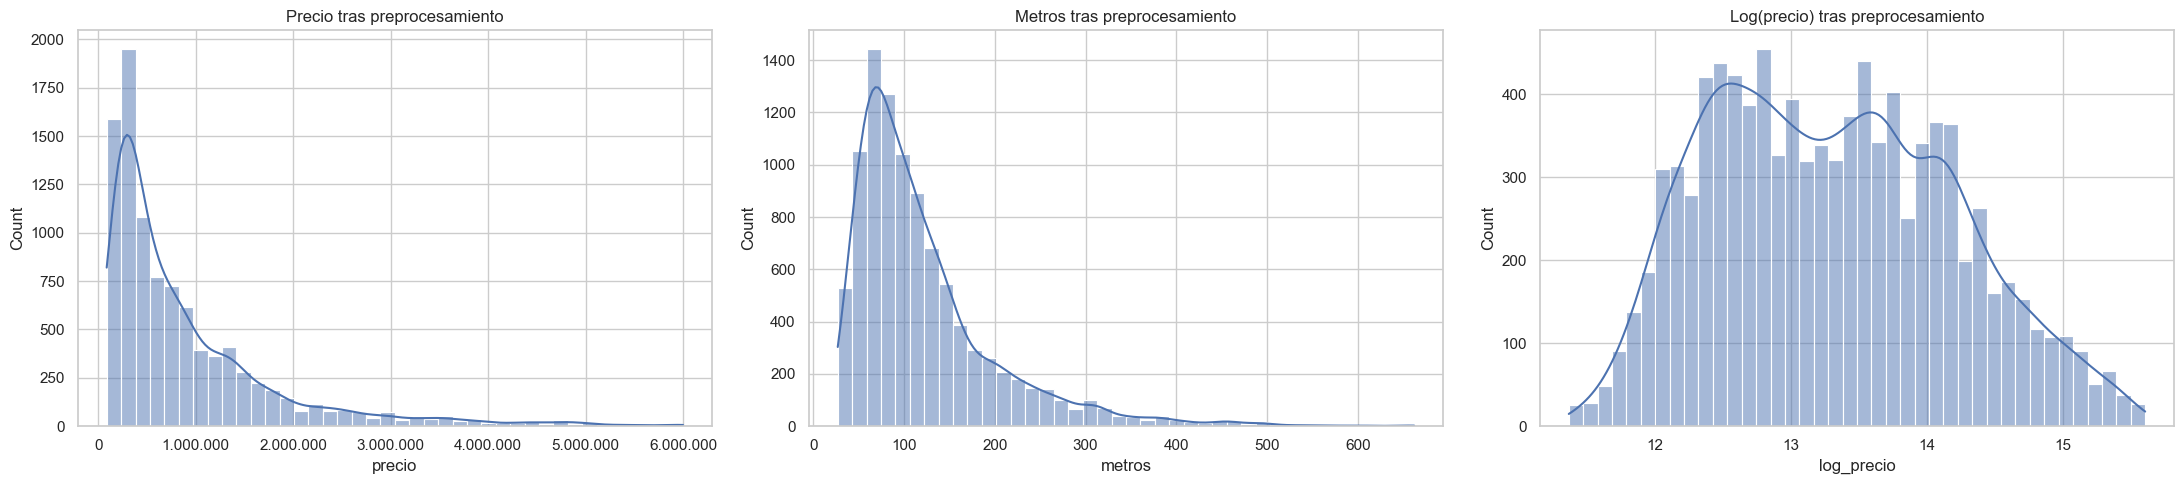

In [794]:
import matplotlib.ticker as ticker

fig, axes = plt.subplots(1, 3, figsize=(22, 5))

sns.histplot(df_pre["precio"], bins=40, kde=True, ax=axes[0])
axes[0].set_title("Precio tras preprocesamiento")
axes[0].xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x:,.0f}".replace(",", "."))
)

sns.histplot(df_pre["metros"], bins=40, kde=True, ax=axes[1])
axes[1].set_title("Metros tras preprocesamiento")

sns.histplot(df_pre["log_precio"], bins=40, kde=True, ax=axes[2])
axes[2].set_title("Log(precio) tras preprocesamiento")


plt.tight_layout()
plt.show()

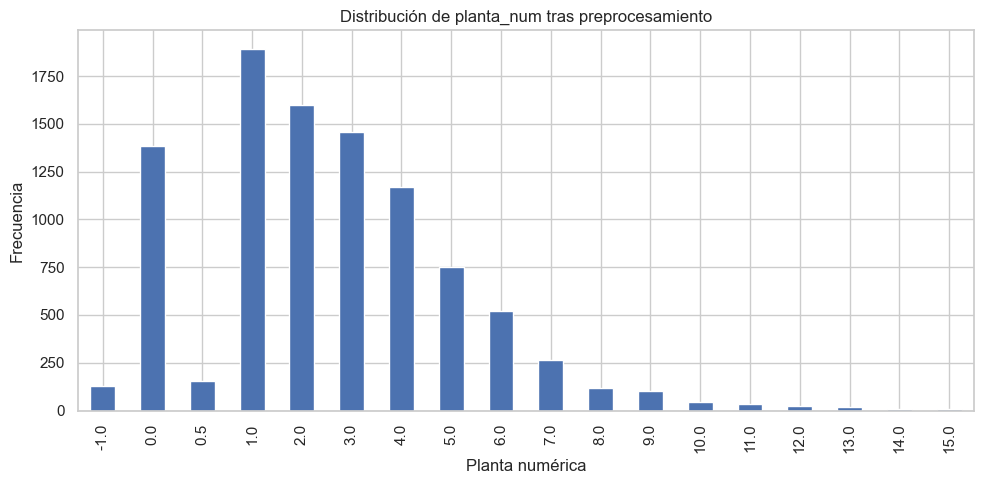

In [795]:
plt.figure(figsize=(10, 5))

df_pre["planta_num"].value_counts(dropna=False).sort_index().plot(kind="bar")

plt.title("Distribución de planta_num tras preprocesamiento")
plt.xlabel("Planta numérica")
plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

## Selección de variables

In [796]:
features = [
    "zona",
    "metros",
    "habitaciones",
    "ascensor",
    "localizacion",
    "baños",
    "planta_num",
    "Distance_to_metro"
]

target = "log_precio"

X = df_pre[features].copy()
y = df_pre[target].copy()

# Minería de datos

## División train/test

In [868]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (7735, 8)
X_test: (1934, 8)
y_train: (7735,)
y_test: (1934,)


## Métricas de evaluación

In [798]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

Función para calcular las métricas

In [799]:
def calcular_metricas(y_real, y_pred, target_log=False):
    if target_log:
        y_real_eval = np.expm1(y_real)
        y_pred_eval = np.expm1(y_pred)
    else:
        y_real_eval = y_real
        y_pred_eval = y_pred
    
    mae = mean_absolute_error(y_real_eval, y_pred_eval)
    mse = mean_squared_error(y_real_eval, y_pred_eval)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_real_eval, y_pred_eval) * 100
    r2 = r2_score(y_real_eval, y_pred_eval)
    
    return mae, mse, rmse, mape, r2

Función para evaluar modelo

In [800]:
def evaluar_modelo(nombre, modelo, X_train, X_test, y_train, y_test):
    modelo.fit(X_train, y_train)
    
    y_pred_train = modelo.predict(X_train)
    y_pred_test = modelo.predict(X_test)
    
    mae_train, mse_train, rmse_train, mape_train, r2_train = calcular_metricas(
        y_train,
        y_pred_train
    )
    
    mae_test, mse_test, rmse_test, mape_test, r2_test = calcular_metricas(
        y_test,
        y_pred_test
    )
    
    return {
        "Modelo": nombre,
        "MAE_train": mae_train,
        "MSE_train": mse_train,
        "RMSE_train": rmse_train,
        "MAPE_train": mape_train,
        "R2_train": r2_train,
        "MAE_test": mae_test,
        "MSE_test": mse_test,
        "RMSE_test": rmse_test,
        "MAPE_test": mape_test,
        "R2_test": r2_test
    }

## Pipelines de preprocesamiento (escalado)

In [801]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_features = [
    "metros",
    "habitaciones",
    "baños",
    "planta_num",
    "Distance_to_metro"
]

categorical_features = [
    "zona",
    "ascensor",
    "localizacion",
]

Pipeline con escalado para los algoritmos: Regresión lineal, LASSO, ElasticNet, SVR, KNN y ANN

In [802]:
numeric_transformer_scaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Desconocido")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_scaled = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_scaled, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

Pipeline sin escalado para algoritmos basados en árboles

In [803]:
numeric_transformer_no_scaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

preprocessor_no_scaled = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_no_scaled, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

Importar modelos

In [804]:
from sklearn.linear_model import LinearRegression, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

Modelos base

In [805]:
modelos_base = {
    "Regresión lineal": Pipeline(steps=[
        ("preprocessor", preprocessor_scaled),
        ("model", LinearRegression())
    ]),
    
    "LASSO": Pipeline(steps=[
        ("preprocessor", preprocessor_scaled),
        ("model", Lasso(
            alpha=0.001,
            max_iter=10000,
            random_state=42
        ))
    ]),
    
    "ElasticNet": Pipeline(steps=[
        ("preprocessor", preprocessor_scaled),
        ("model", ElasticNet(
            alpha=0.001,
            l1_ratio=0.5,
            max_iter=10000,
            random_state=42
        ))
    ]),
    
    "SVR": Pipeline(steps=[
        ("preprocessor", preprocessor_scaled),
        ("model", SVR())
    ]),
    
    "KNN": Pipeline(steps=[
        ("preprocessor", preprocessor_scaled),
        ("model", KNeighborsRegressor())
    ]),
    
    "Random Forest": Pipeline(steps=[
        ("preprocessor", preprocessor_no_scaled),
        ("model", RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ))
    ]),
    
    "XGBoost": Pipeline(steps=[
        ("preprocessor", preprocessor_no_scaled),
        ("model", XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        ))
    ]),
    
    "CatBoost": Pipeline(steps=[
        ("preprocessor", preprocessor_no_scaled),
        ("model", CatBoostRegressor(
            iterations=300,
            learning_rate=0.05,
            depth=6,
            loss_function="RMSE",
            random_seed=42,
            verbose=0
        ))
    ]),
    
    "ANN": Pipeline(steps=[
        ("preprocessor", preprocessor_scaled),
        ("model", MLPRegressor(
            hidden_layer_sizes=(128, 64),
            activation="relu",
            solver="adam",
            alpha=0.0001,
            learning_rate_init=0.001,
            max_iter=500,
            early_stopping=True,
            random_state=42
        ))
    ])
}

## Entrenamiento y evaluación de modelos

Entrenamiento y evaluación inicial (con validación cruzada con k=5)

In [806]:
from sklearn.model_selection import KFold
from sklearn.base import clone

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

target_log=True

resultados_cv = []
resultados_cv_folds = []

for nombre, modelo in modelos_base.items():
    print(f"Validación cruzada para {nombre}...")
    
    metricas_folds = []
    
    for fold, (train_idx, val_idx) in enumerate(cv.split(X_train), start=1):
        X_tr = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]
        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]
        
        modelo_fold = clone(modelo)
        modelo_fold.fit(X_tr, y_tr)
        
        y_pred_val = modelo_fold.predict(X_val)
        
        mae, mse, rmse, mape, r2 = calcular_metricas(
            y_val,
            y_pred_val,
            target_log=target_log
        )
        
        metricas_fold = {
            "Modelo": nombre,
            "Fold": fold,
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse,
            "MAPE": mape,
            "R2": r2
        }
        
        metricas_folds.append(metricas_fold)
        resultados_cv_folds.append(metricas_fold)
    
    metricas_folds_df = pd.DataFrame(metricas_folds)
    
    resultados_cv.append({
        "Modelo": nombre,
        "MAE": metricas_folds_df["MAE"].mean(),

        "MSE": metricas_folds_df["MSE"].mean(),

        "RMSE": metricas_folds_df["RMSE"].mean(),

        "MAPE": metricas_folds_df["MAPE"].mean(),

        "R2": metricas_folds_df["R2"].mean(),

    })

resultados_cv_df = pd.DataFrame(resultados_cv)
resultados_cv_df = resultados_cv_df.sort_values("RMSE")

display(resultados_cv_df.round(4))

Validación cruzada para Regresión lineal...
Validación cruzada para LASSO...
Validación cruzada para ElasticNet...
Validación cruzada para SVR...
Validación cruzada para KNN...
Validación cruzada para Random Forest...
Validación cruzada para XGBoost...
Validación cruzada para CatBoost...
Validación cruzada para ANN...


,Modelo,MAE,MSE,RMSE,MAPE,R2
6,XGBoost,"177.357,08","105.980.458.484,29","325.221,86","20,91","0,87"
5,Random Forest,"183.152,93","117.636.508.154,14","342.504,26","21,95","0,86"
7,CatBoost,"190.616,66","120.133.799.569,88","346.363,14","22,06","0,86"
3,SVR,"190.694,06","125.369.199.529,45","353.343,19","22,08","0,85"
8,ANN,"200.782,92","149.474.832.374,16","381.737,01","23,43","0,82"
4,KNN,"221.780,46","157.478.968.062,99","396.264,75","27,61","0,81"
0,Regresión lineal,"268.982,03","430.270.612.654,06","653.218,19","28,03","0,49"
2,ElasticNet,"270.508,33","444.273.947.966,05","663.635,91","28,03","0,47"
1,LASSO,"271.378,00","451.151.438.006,61","668.729,27","28,08","0,46"


Gráficos de comparación de modelos

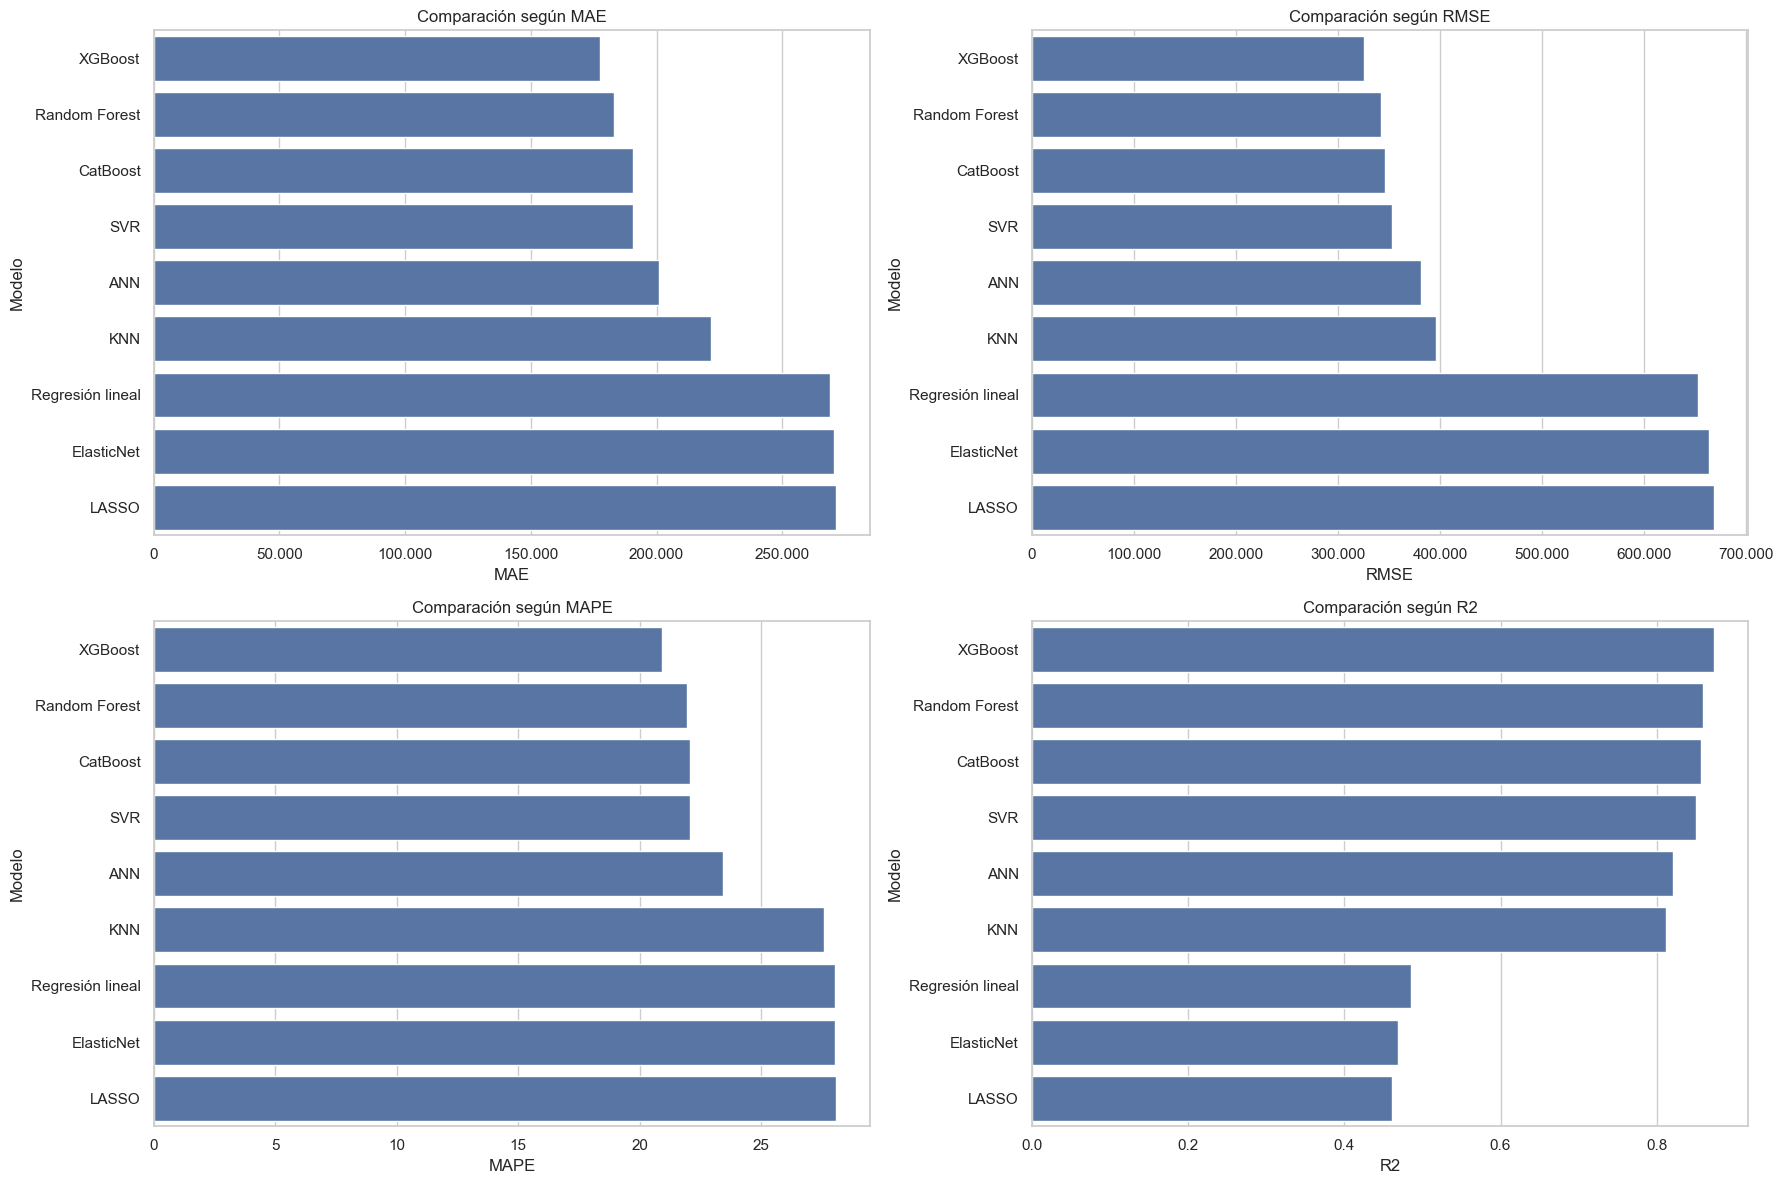

In [807]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

metricas = [
    ("MAE", True),
    ("RMSE", True),
    ("MAPE", True),
    ("R2", False)
]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for ax, (metrica, menor_es_mejor) in zip(axes, metricas):
    
    datos_ordenados = resultados_cv_df.sort_values(
        metrica,
        ascending=menor_es_mejor
    )
    
    sns.barplot(
        data=datos_ordenados,
        x=metrica,
        y="Modelo",
        ax=ax
    )
    
    ax.set_title(f"Comparación según {metrica}")
    ax.set_xlabel(metrica)
    ax.set_ylabel("Modelo")
    
    if metrica in ["MAE", "RMSE"]:
        ax.xaxis.set_major_formatter(
            ticker.FuncFormatter(lambda x, pos: f"{x:,.0f}".replace(",", "."))
        )

plt.tight_layout()
plt.show()

## Selección del mejor modelo y optimización de hiperparámetros con Randomized o Grid Search

In [808]:
top_modelos = resultados_cv_df.head(3)["Modelo"].tolist()

print("Modelos seleccionados para ajuste de hiperparámetros:")
print(top_modelos)

Modelos seleccionados para ajuste de hiperparámetros:
['XGBoost', 'Random Forest', 'CatBoost']


Optimización de hiperparámetros

In [809]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

Random Forest

In [810]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_no_scaled),
    ("model", RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

rf_param_grid = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None]
}

XGBoost

In [811]:
xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_no_scaled),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])

xgb_param_grid = {
    "model__n_estimators": [200, 300, 500],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [3, 5, 7],
    "model__subsample": [0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 1.0]
}

CatBoost

In [812]:
cat_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_no_scaled),
    ("model", CatBoostRegressor(
        loss_function="RMSE",
        random_seed=42,
        verbose=0
    ))
])

cat_param_grid = {
    "model__iterations": [200, 300, 500],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__depth": [4, 6, 8],
    "model__l2_leaf_reg": [1, 3, 5, 7]
}

In [813]:
busquedas = {
    "Random Forest": {
        "pipeline": rf_pipeline,
        "param_grid": rf_param_grid,
        "tipo": "random",
        "n_iter": 20
    },
    "XGBoost": {
        "pipeline": xgb_pipeline,
        "param_grid": xgb_param_grid,
        "tipo": "random",
        "n_iter": 20
    },
    "CatBoost": {
        "pipeline": cat_pipeline,
        "param_grid": cat_param_grid,
        "tipo": "random",
        "n_iter": 20
    }
}

In [814]:
modelos_ajustados = {}
resultados_ajuste = []

for nombre in top_modelos:
    print(f"\nAjustando hiperparámetros para {nombre}...")
    
    config = busquedas[nombre]
    
    if config["tipo"] == "grid":
        search = GridSearchCV(
            estimator=config["pipeline"],
            param_grid=config["param_grid"],
            cv=5,
            scoring="neg_root_mean_squared_error",
            n_jobs=-1
        )
    else:
        search = RandomizedSearchCV(
            estimator=config["pipeline"],
            param_distributions=config["param_grid"],
            n_iter=config["n_iter"],
            cv=5,
            scoring="neg_root_mean_squared_error",
            random_state=42,
            n_jobs=-1
        )
    
    search.fit(X_train, y_train)
    
    modelos_ajustados[nombre] = search.best_estimator_
    
    resultados_ajuste.append({
        "Modelo": nombre,
        "Mejor_RMSE_CV": -search.best_score_,
        "Mejores_hiperparametros": search.best_params_
    })

resultados_ajuste_df = pd.DataFrame(resultados_ajuste)
resultados_ajuste_df = resultados_ajuste_df.sort_values("Mejor_RMSE_CV")

with pd.option_context('display.max_colwidth', None):
    display(resultados_ajuste_df)


Ajustando hiperparámetros para XGBoost...

Ajustando hiperparámetros para Random Forest...

Ajustando hiperparámetros para CatBoost...


,Modelo,Mejor_RMSE_CV,Mejores_hiperparametros
0,XGBoost,"0,26","{'model__subsample': 0.7, 'model__n_estimators': 500, 'model__max_depth': 5, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.8}"
2,CatBoost,"0,26","{'model__learning_rate': 0.1, 'model__l2_leaf_reg': 1, 'model__iterations': 500, 'model__depth': 6}"
1,Random Forest,"0,27","{'model__n_estimators': 500, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': None}"


In [819]:
with pd.option_context('display.max_colwidth', None):
    display(resultados_ajuste_df)

,Modelo,Mejor_RMSE_CV,Mejores_hiperparametros
0,XGBoost,"0,26","{'model__subsample': 0.7, 'model__n_estimators': 500, 'model__max_depth': 5, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.8}"
2,CatBoost,"0,26","{'model__learning_rate': 0.1, 'model__l2_leaf_reg': 1, 'model__iterations': 500, 'model__depth': 6}"
1,Random Forest,"0,27","{'model__n_estimators': 500, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': None}"


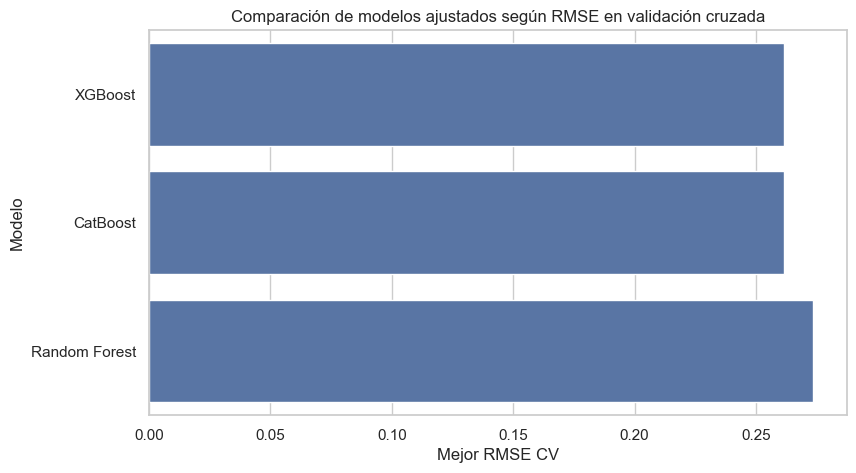

In [820]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=resultados_ajuste_df,
    x="Mejor_RMSE_CV",
    y="Modelo"
)

plt.title("Comparación de modelos ajustados según RMSE en validación cruzada")
plt.xlabel("Mejor RMSE CV")
plt.ylabel("Modelo")
plt.show()

In [ ]:
mejor_modelo_nombre = resultados_ajuste_df.iloc[0]["Modelo"]
mejor_modelo = modelos_ajustados[mejor_modelo_nombre]

print("Mejor modelo ajustado según CV:", mejor_modelo_nombre)

Mejor modelo ajustado según CV: CatBoost


Entrenamiento del mejor modelo

In [839]:
mejor_modelo.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [840]:
y_pred_test = mejor_modelo.predict(X_test)

mae, mse, rmse, mape, r2 = calcular_metricas(
    y_test,
    y_pred_test,
    target_log=target_log
)

resultado_test_final = pd.DataFrame({
    "Modelo": [mejor_modelo_nombre],
    "MAE_test": [mae],
    "MSE_test": [mse],
    "RMSE_test": [rmse],
    "MAPE_test": [mape],
    "R2_test": [r2]
})

display(resultado_test_final.round(4))

,Modelo,MAE_test,MSE_test,RMSE_test,MAPE_test,R2_test
0,CatBoost,"168.836,06","96.304.879.426,76","310.330,27","19,51","0,89"


# Interpretabilidad

In [858]:
preprocessor_fitted = mejor_modelo.named_steps["preprocessor"]
modelo_fitted = mejor_modelo.named_steps["model"]

print(type(preprocessor_fitted))
print(type(modelo_fitted))

<class 'sklearn.compose._column_transformer.ColumnTransformer'>
<class 'catboost.core.CatBoostRegressor'>


In [859]:
def obtener_nombres_variables(preprocessor, numeric_features, categorical_features):
    # Nombres de variables numéricas
    num_names = numeric_features
    
    # Nombres de variables categóricas tras One-Hot Encoding
    cat_encoder = preprocessor.named_transformers_["cat"].named_steps["onehot"]
    cat_names = cat_encoder.get_feature_names_out(categorical_features)
    
    # Unión de nombres
    feature_names = np.concatenate([num_names, cat_names])
    
    return feature_names

In [860]:
feature_names = obtener_nombres_variables(
    preprocessor_fitted,
    numeric_features,
    categorical_features
)

print("Número de variables tras codificación:", len(feature_names))
print(feature_names[:20])

Número de variables tras codificación: 32
['metros' 'habitaciones' 'baños' 'planta_num' 'Distance_to_metro'
 'zona_arganzuela' 'zona_barajas' 'zona_barrio-de-salamanca'
 'zona_carabanchel' 'zona_centro' 'zona_chamartin' 'zona_chamberi'
 'zona_ciudad-lineal' 'zona_fuencarral' 'zona_hortaleza' 'zona_latina'
 'zona_moncloa' 'zona_moratalaz' 'zona_puente-de-vallecas' 'zona_retiro']


In [861]:
X_train_transformed = preprocessor_fitted.transform(X_train)
X_test_transformed = preprocessor_fitted.transform(X_test)

if hasattr(X_train_transformed, "toarray"):
    X_train_transformed = X_train_transformed.toarray()

if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

print("X_train transformado:", X_train_transformed.shape)
print("X_test transformado:", X_test_transformed.shape)

X_train transformado: (7735, 32)
X_test transformado: (1934, 32)


## Feature Importance

In [862]:
importances = modelo_fitted.feature_importances_

importance_df = pd.DataFrame({
    "Variable": feature_names,
    "Importancia": importances
}).sort_values("Importancia", ascending=False)

display(importance_df.head(30))

,Variable,Importancia
0,metros,"42,45"
7,zona_barrio-de-salamanca,"11,62"
4,Distance_to_metro,"9,45"
3,planta_num,"4,29"
9,zona_centro,"3,98"
28,ascensor_S,"3,55"
27,ascensor_N,"3,04"
11,zona_chamberi,"2,91"
25,zona_villaverde,"2,25"
1,habitaciones,"2,17"


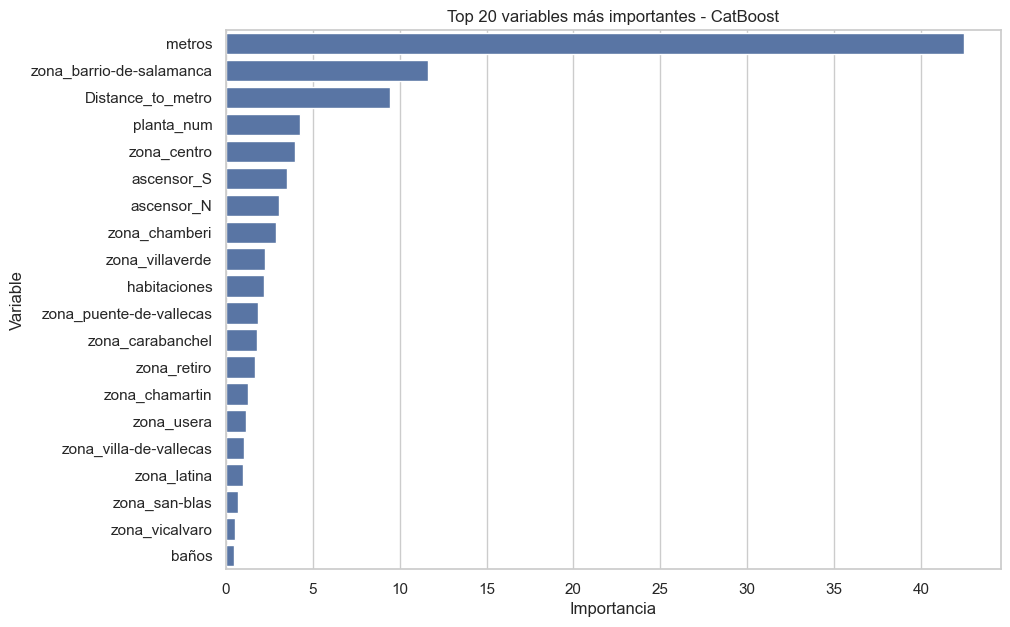

In [863]:
top_importance = importance_df.head(20)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_importance,
    x="Importancia",
    y="Variable"
)

plt.title("Top 20 variables más importantes - CatBoost")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()

Agrupando variables categóricas dummy en la variable original

In [864]:
def agrupar_importancia_por_variable_original(importance_df, numeric_features, categorical_features):
    df_grouped = importance_df.copy()
    
    def obtener_variable_original(nombre):
        if nombre in numeric_features:
            return nombre
        
        for cat in categorical_features:
            if nombre.startswith(cat + "_"):
                return cat
        
        return nombre
    
    df_grouped["Variable_original"] = df_grouped["Variable"].apply(obtener_variable_original)
    
    agrupado = (
        df_grouped
        .groupby("Variable_original")["Importancia"]
        .sum()
        .sort_values(ascending=False)
        .reset_index()
    )
    
    return agrupado

In [866]:
importance_agrupada_df = agrupar_importancia_por_variable_original(
    importance_df,
    numeric_features,
    categorical_features
)

display(importance_agrupada_df)

,Variable_original,Importancia
0,metros,"42,45"
1,zona,"33,89"
2,Distance_to_metro,"9,45"
3,ascensor,"6,66"
4,planta_num,"4,29"
5,habitaciones,"2,17"
6,localizacion,"0,58"
7,baños,"0,50"


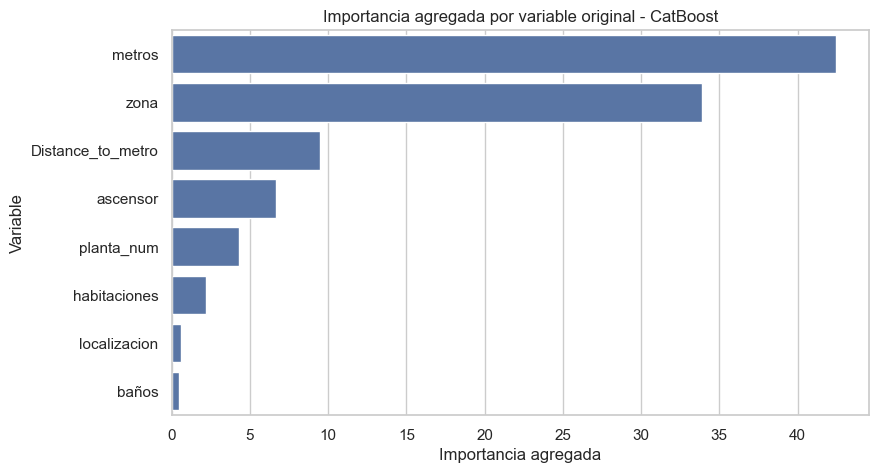

In [867]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=importance_agrupada_df,
    x="Importancia",
    y="Variable_original"
)

plt.title("Importancia agregada por variable original - CatBoost")
plt.xlabel("Importancia agregada")
plt.ylabel("Variable")
plt.show()

## SHAP

In [854]:
import shap

X_shap = X_test_transformed

print("Filas usadas para SHAP:", X_shap.shape[0])
print("Columnas usadas para SHAP:", X_shap.shape[1])

explainer = shap.Explainer(modelo_fitted, X_shap)
shap_values = explainer(X_shap)

Filas usadas para SHAP: 1934
Columnas usadas para SHAP: 32


 99%|===================| 1918/1934 [00:20<00:00]        

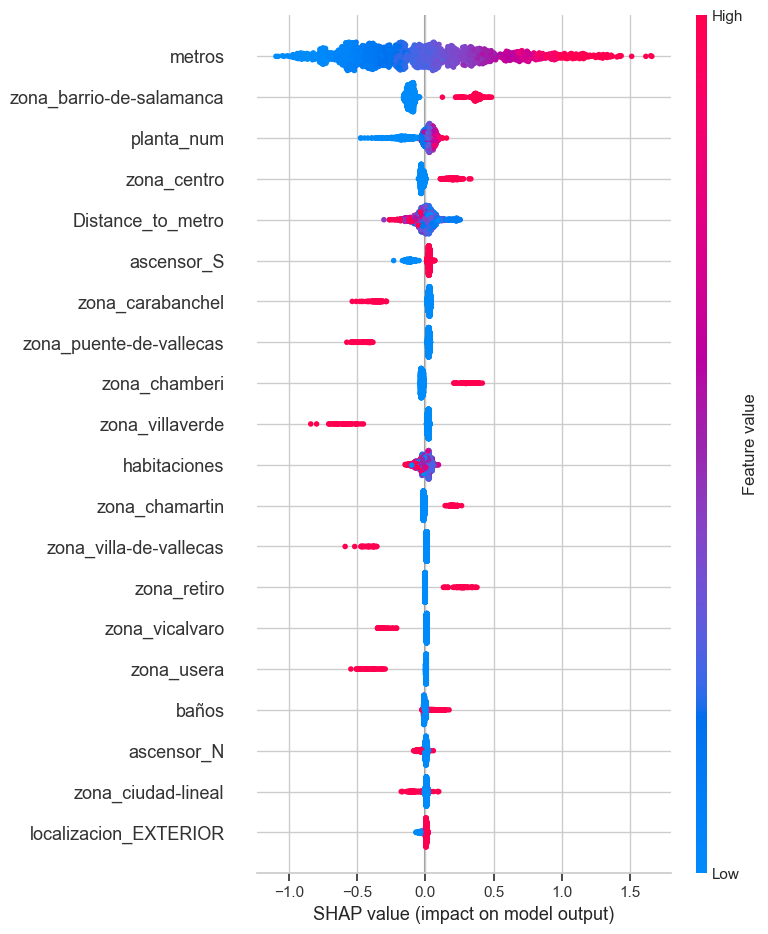

In [855]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names
)

In [856]:
def agrupar_shap_por_variable_original(shap_importance_df, numeric_features, categorical_features):
    df_grouped = shap_importance_df.copy()
    
    def obtener_variable_original(nombre):
        if nombre in numeric_features:
            return nombre
        
        for cat in categorical_features:
            if nombre.startswith(cat + "_"):
                return cat
        
        return nombre
    
    df_grouped["Variable_original"] = df_grouped["Variable"].apply(obtener_variable_original)
    
    agrupado = (
        df_grouped
        .groupby("Variable_original")["Importancia_SHAP_media"]
        .sum()
        .sort_values(ascending=False)
        .reset_index()
    )
    
    return agrupado

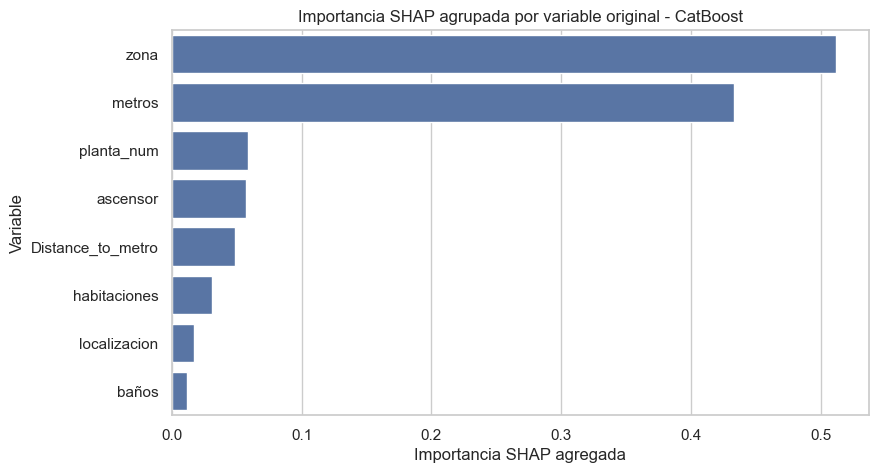

In [857]:
shap_importance = np.abs(shap_values.values).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "Variable": feature_names,
    "Importancia_SHAP_media": shap_importance
}).sort_values("Importancia_SHAP_media", ascending=False)

shap_importance_agrupada_df = agrupar_shap_por_variable_original(
    shap_importance_df,
    numeric_features,
    categorical_features
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=shap_importance_agrupada_df,
    x="Importancia_SHAP_media",
    y="Variable_original"
)

plt.title("Importancia SHAP agrupada por variable original - CatBoost")
plt.xlabel("Importancia SHAP agregada")
plt.ylabel("Variable")
plt.show()